C:\Users\Esquivo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.stats import gaussian_kde


📊 RESUMO DE METRICAS PRINCIPAIS
💰 Faturamento Concluído : R$ 12,184,084.69
🎟️ Ticket Médio           : R$ 2,408.87
📅 Total de Agendamentos  : 20,000
❌ Taxa de Absenteísmo    : 25.05%



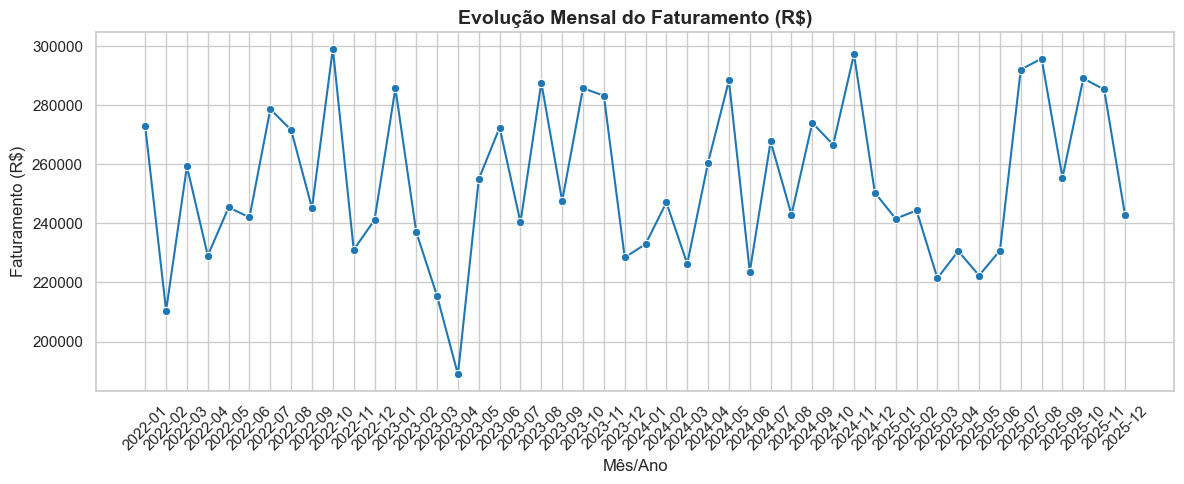

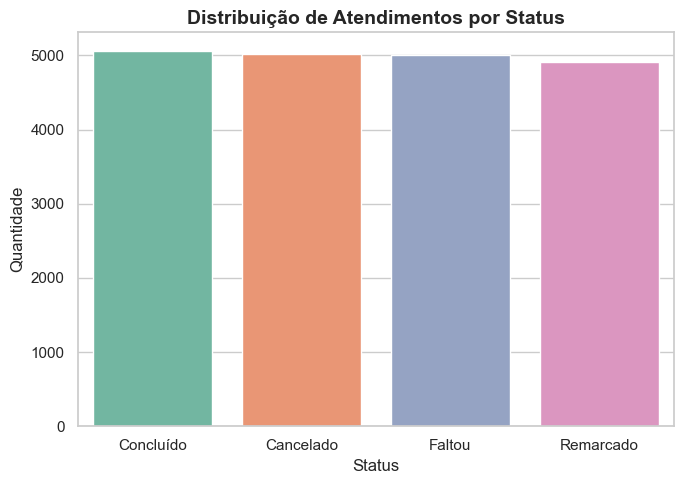

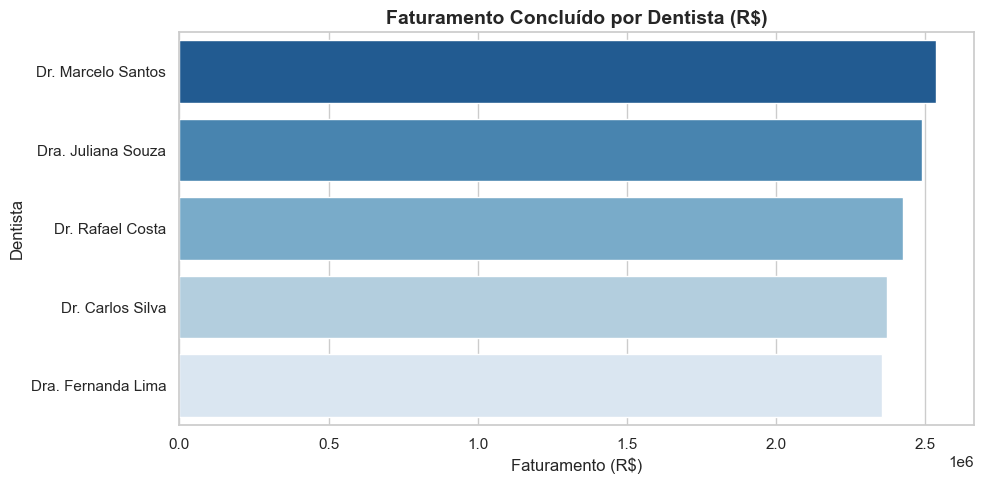

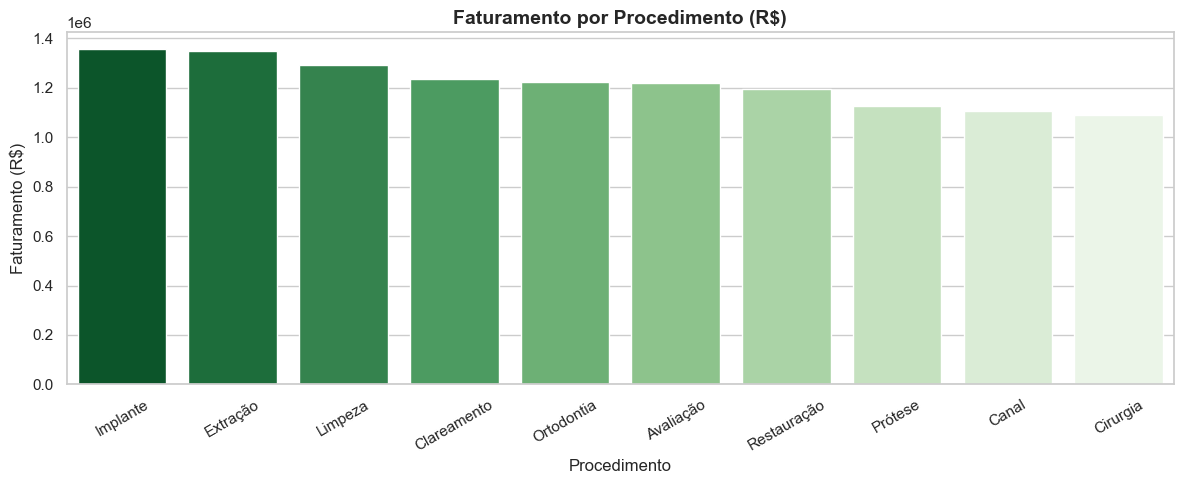

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configuração visual do Seaborn/Matplotlib
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


# 1. Carregamento e Tratamento dos Dados
def carregar_e_tratar_dados():
    try:
        df = pd.read_csv(
            "Base_Servicos_Odontologicos_Consolidada.xlsx - Sheet1.csv"
        )
    except Exception:
        df = pd.read_excel("Base_Servicos_Odontologicos_Consolidada.xlsx")

    # Conversão de tipos
    df["DATA_ATENDIMENTO"] = pd.to_datetime(df["DATA_ATENDIMENTO"])
    df["VALOR_SERVICO"] = (
        pd.to_numeric(df["VALOR_SERVICO"], errors="coerce")
        .fillna(0)
        .clip(lower=0)
    )

    # Colunas de data
    df["ANO"] = df["DATA_ATENDIMENTO"].dt.year
    df["MES_ANO"] = df["DATA_ATENDIMENTO"].dt.strftime("%Y-%m")

    return df


df = carregar_e_tratar_dados()

# 2. Resumo de Métricas Globais (KPIs)
df_concluidos = df[df["STATUS"] == "Concluído"]

faturamento_total = df_concluidos["VALOR_SERVICO"].sum()
total_agendamentos = len(df)
total_concluidos = len(df_concluidos)
ticket_medio = (
    faturamento_total / total_concluidos if total_concluidos > 0 else 0
)
taxa_absenteismo = (
    (len(df[df["STATUS"] == "Faltou"]) / total_agendamentos) * 100
    if total_agendamentos > 0
    else 0
)

print("=" * 45)
print("📊 RESUMO DE METRICAS PRINCIPAIS")
print("=" * 45)
print(f"💰 Faturamento Concluído : R$ {faturamento_total:,.2f}")
print(f"🎟️ Ticket Médio           : R$ {ticket_medio:,.2f}")
print(f"📅 Total de Agendamentos  : {total_agendamentos:,}")
print(f"❌ Taxa de Absenteísmo    : {taxa_absenteismo:.2f}%")
print("=" * 45 + "\n")

# ---------------------------------------------------------
# 3. GERAÇÃO DOS GRÁFICOS
# ---------------------------------------------------------

# Gráfico 1: Evolução Mensal do Faturamento
plt.figure(figsize=(12, 5))
df_fat_mes = (
    df_concluidos.groupby("MES_ANO")["VALOR_SERVICO"].sum().reset_index()
)
sns.lineplot(
    data=df_fat_mes, x="MES_ANO", y="VALOR_SERVICO", marker="o", color="#1f77b4"
)
plt.title("Evolução Mensal do Faturamento (R$)", fontsize=14, fontweight="bold")
plt.xlabel("Mês/Ano")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gráfico 2: Distribuição por Status do Atendimento
plt.figure(figsize=(7, 5))
df_status = df["STATUS"].value_counts().reset_index()
df_status.columns = ["STATUS", "QUANTIDADE"]
sns.barplot(
    data=df_status,
    x="STATUS",
    y="QUANTIDADE",
    palette="Set2",
    hue="STATUS",
    legend=False,
)
plt.title("Distribuição de Atendimentos por Status", fontsize=14, fontweight="bold")
plt.xlabel("Status")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

# Gráfico 3: Faturamento por Dentista
plt.figure(figsize=(10, 5))
df_dentista = (
    df_concluidos.groupby("DENTISTA")["VALOR_SERVICO"]
    .sum()
    .reset_index()
    .sort_values(by="VALOR_SERVICO", ascending=False)
)
sns.barplot(
    data=df_dentista,
    y="DENTISTA",
    x="VALOR_SERVICO",
    palette="Blues_r",
    hue="DENTISTA",
    legend=False,
)
plt.title(
    "Faturamento Concluído por Dentista (R$)", fontsize=14, fontweight="bold"
)
plt.xlabel("Faturamento (R$)")
plt.ylabel("Dentista")
plt.tight_layout()
plt.show()

# Gráfico 4: Faturamento por Procedimento
plt.figure(figsize=(12, 5))
df_proc = (
    df_concluidos.groupby("PROCEDIMENTO")["VALOR_SERVICO"]
    .sum()
    .reset_index()
    .sort_values(by="VALOR_SERVICO", ascending=False)
)
sns.barplot(
    data=df_proc,
    x="PROCEDIMENTO",
    y="VALOR_SERVICO",
    palette="Greens_r",
    hue="PROCEDIMENTO",
    legend=False,
)
plt.title("Faturamento por Procedimento (R$)", fontsize=14, fontweight="bold")
plt.xlabel("Procedimento")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()